In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset_path = "/content/drive/MyDrive/Garbage classification/Garbage classification"

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

train = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.3195 - loss: 1.6397 - val_accuracy: 0.4099 - val_loss: 1.4219
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 732ms/step - accuracy: 0.4535 - loss: 1.3722 - val_accuracy: 0.3584 - val_loss: 1.5185
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 736ms/step - accuracy: 0.5188 - loss: 1.2371 - val_accuracy: 0.5465 - val_loss: 1.2318
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 736ms/step - accuracy: 0.5870 - loss: 1.1198 - val_accuracy: 0.5762 - val_loss: 1.0551
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 734ms/step - accuracy: 0.6256 - loss: 1.0224 - val_accuracy: 0.6000 - val_loss: 1.0545
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 740ms/step - accuracy: 0.6790 - loss: 0.9077 - val_accuracy: 0.6257 - val_loss: 0.9550
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 769ms/step - accuracy: 0.7082 - loss: 0.8168 - val_accuracy: 0.6396 - val_loss: 0.9704
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 792ms/step - accuracy: 0.7240 - loss: 0.7380 - val_accuracy: 0.6851 

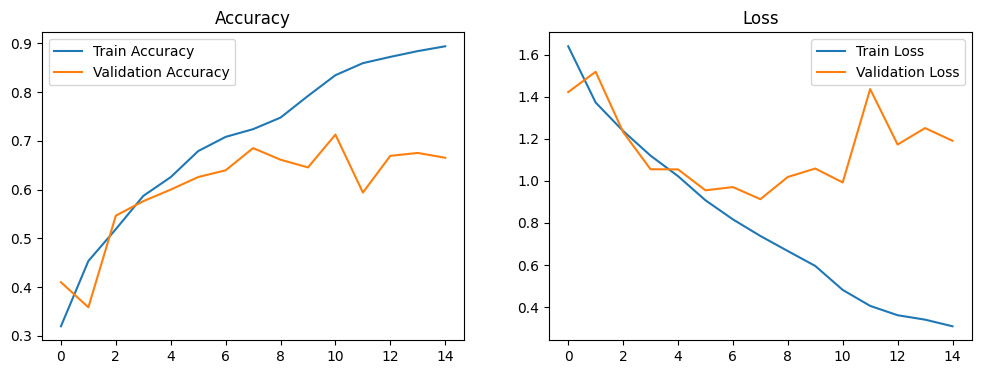

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Garbage classification/Garbage classification"

img_size = (128, 128)
batch_size = 32
seed = 42

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=img_size + (3,)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [10]:
predictions = model.predict(val_ds)

print("First 5 predictions:")
print(predictions[:5])

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step
First 5 predictions:
[[1.78450737e-02 1.21625088e-01 1.35083303e-01 6.66258812e-01
  5.90729564e-02 1.14793474e-04]
 [1.45554281e-04 9.38185491e-03 1.92359522e-01 7.48603269e-02
  7.23059952e-01 1.92781779e-04]
 [3.48976473e-11 7.90163313e-09 3.11928918e-03 9.96880710e-01
  1.19025039e-08 7.43846512e-11]
 [9.98391569e-01 4.19511744e-05 1.07064068e-06 1.54276984e-06
  1.37383933e-03 1.90070583e-04]
 [1.68509156e-04 1.36284828e-01 6.74422085e-03 7.24457577e-03
  9.89451911e-03 8.39663327e-01]]


In [12]:
predictions = model.predict(val_ds)

print("First 5 predictions:")
for i in range(5):
    print(f"Prediction {i+1}: {predictions[i]}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 241ms/step
First 5 predictions:
Prediction 1: [1.78450737e-02 1.21625088e-01 1.35083303e-01 6.66258812e-01
 5.90729564e-02 1.14793474e-04]
Prediction 2: [1.4555428e-04 9.3818549e-03 1.9235952e-01 7.4860327e-02 7.2305995e-01
 1.9278178e-04]
Prediction 3: [3.4897647e-11 7.9016331e-09 3.1192892e-03 9.9688071e-01 1.1902504e-08
 7.4384651e-11]
Prediction 4: [9.9839157e-01 4.1951174e-05 1.0706407e-06 1.5427698e-06 1.3738393e-03
 1.9007058e-04]
Prediction 5: [1.6850916e-04 1.3628483e-01 6.7442209e-03 7.2445758e-03 9.8945191e-03
 8.3966333e-01]


In [14]:
import numpy as np

predictions = model.predict(val_ds)
predicted_classes = np.argmax(predictions, axis=1)

print("First 5 predictions (class indices):")
print(predicted_classes[:5])

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step
First 5 predictions (class indices):
[3 4 3 0 5]


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 709ms/step - accuracy: 0.3091 - loss: 1.6529 - val_accuracy: 0.4099 - val_loss: 1.4392
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 684ms/step - accuracy: 0.4031 - loss: 1.4513 - val_accuracy: 0.4158 - val_loss: 1.4043
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 693ms/step - accuracy: 0.4847 - loss: 1.3130 - val_accuracy: 0.4911 - val_loss: 1.2308
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 663ms/step - accuracy: 0.4990 - loss: 1.2762 - val_accuracy: 0.5089 - val_loss: 1.2351
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 683ms/step - accuracy: 0.5445 - loss: 1.2029 - val_accuracy: 0.5644 - val_loss: 1.1992
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 212ms/step - accuracy: 0.5644 - loss: 1.1992
Validation Accuracy: 0.5643564462661743
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Image 1
Actual    : glass
Predicted : glass
------------------------------


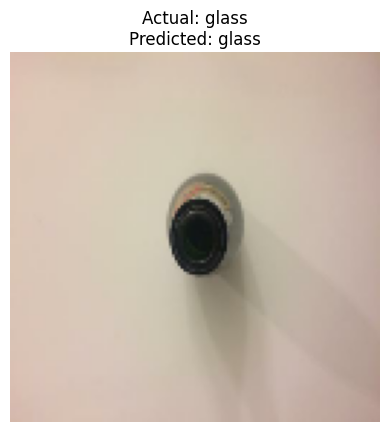

Image 2
Actual    : trash
Predicted : trash
------------------------------


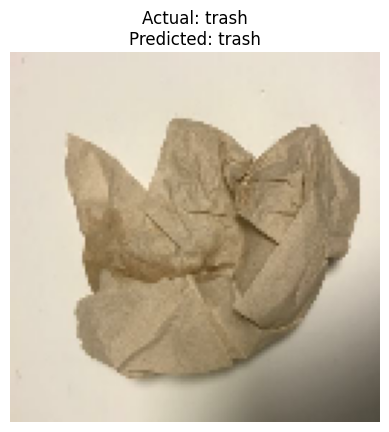

Image 3
Actual    : glass
Predicted : plastic
------------------------------


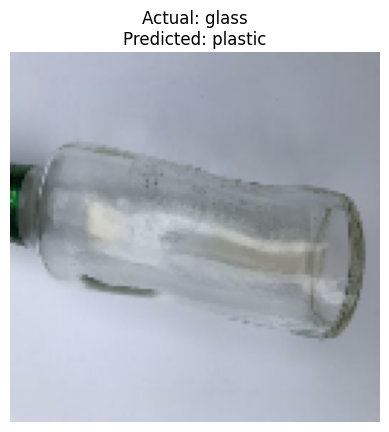

Image 4
Actual    : plastic
Predicted : plastic
------------------------------


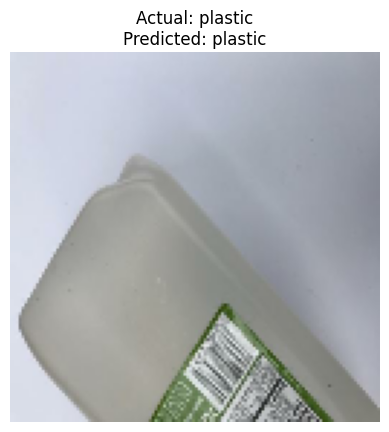

Image 5
Actual    : glass
Predicted : glass
------------------------------


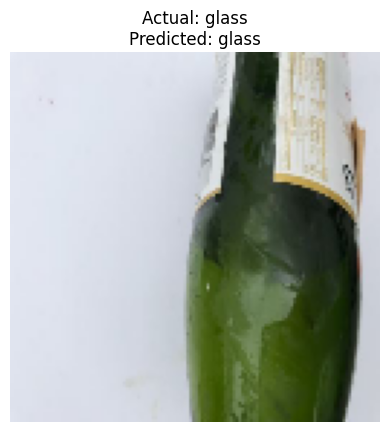

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
)

# Set your dataset path here
dataset_path = "/content/drive/MyDrive/Garbage classification/Garbage classification"

# Load training and validation datasets
train = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

val = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# Get class names automatically from folder names
classes = train.class_names
print("Classes:", classes)

# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x, y: (normalization_layer(x), y))
val = val.map(lambda x, y: (normalization_layer(x), y))

# Improve performance
train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)

# Build CNN model
model = Sequential()

model.add(Input(shape=(128, 128, 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(classes), activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

# Train model
history = model.fit(
    train,
    validation_data=val,
    epochs=5
)

# Evaluate model
loss, accuracy = model.evaluate(val)
print("Validation Accuracy:", accuracy)

# Get first batch from validation set
for images, labels in val.take(1):
    predictions = model.predict(images[:5])

    for i in range(5):
        predicted_label = np.argmax(predictions[i])
        actual_label = labels[i].numpy()

        print(f"Image {i+1}")
        print(f"Actual    : {classes[actual_label]}")
        print(f"Predicted : {classes[predicted_label]}")
        print("-" * 30)

        plt.imshow(images[i].numpy())
        plt.title(
            f"Actual: {classes[actual_label]}\n"
            f"Predicted: {classes[predicted_label]}"
        )
        plt.axis("off")
        plt.show()